In [1]:
import os
import numpy as np
import pandas as pd
import kagglehub
import pickle
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler, QuantileTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor 
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, make_scorer, root_mean_squared_error, r2_score, f1_score

In [29]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mosapabdelghany/medical-insurance-cost-dataset")
#path= path.replace('.cache', 'Documents')
print("Path to dataset files:", path)
path=r'/Users/imohekpenyong/.cache/kagglehub/datasets/mosapabdelghany/medical-insurance-cost-dataset/versions/1/insurance.csv'

Path to dataset files: /Users/imohekpenyong/.cache/kagglehub/datasets/mosapabdelghany/medical-insurance-cost-dataset/versions/1


In [3]:
path= '/Users/imohekpenyong/.cache/kagglehub/datasets/mosapabdelghany/medical-insurance-cost-dataset/versions/1'
df= pd.read_csv(f'{path}/insurance.csv')

In [4]:
print(f'{df.head()}, \n \n {df.info()}, \n \n {df.dtypes}, \n \n {df.shape}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520, 
 
 None, 
 
 age           int64
sex          object
bmi         float64
children      int64
s

In [5]:
X, y= df.iloc[:, :-1], df.iloc[:, -1]
categories=y.map(lambda x: 'LOW RISK' if x <15000 else 'HIGH RISK')
categories.value_counts(normalize=True)

charges
LOW RISK     0.732436
HIGH RISK    0.267564
Name: proportion, dtype: float64

In [24]:
num_col=[cols for cols in X.columns if df[cols].dtype != 'object']
cat_col=[cols for cols in X.columns if df[cols].dtype == 'object']
print(cat_col, num_col, categories.dtype)

['sex', 'smoker', 'region'] ['age', 'bmi', 'children'] object


In [7]:
cols= df.select_dtypes(include=[np.number])
cols.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [273]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


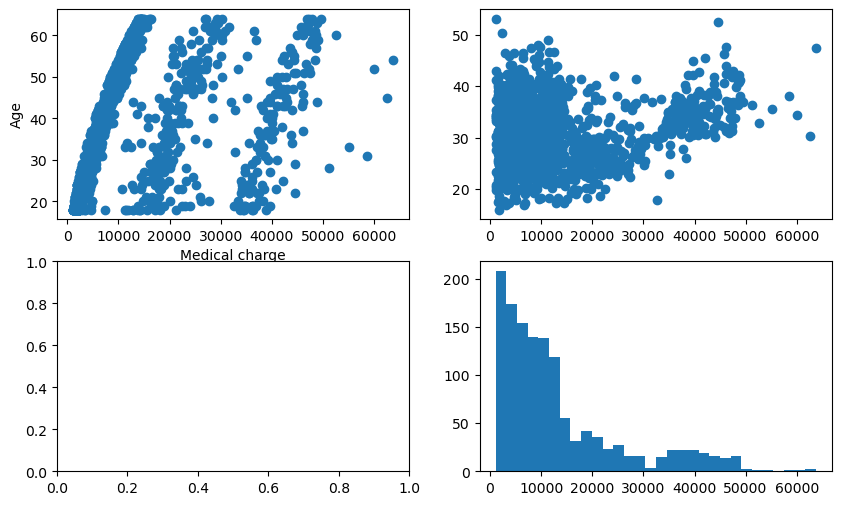

In [233]:
%matplotlib inline
fig, ax=plt.subplots(2,2, figsize=(10,6))
ax[0,0].scatter(df.charges, df.age)
ax[0,0].set_ylabel('Age')
ax[0,0].set_xlabel('Medical charge')
ax[0,1].scatter(df.charges, df.bmi)
ax[1,1].hist(df.charges, bins='fd')
plt.show()

## Regression Task

In [11]:
Xtrain, Xtest, ytrain, ytest=train_test_split(X, y, test_size=0.25, shuffle=True, random_state=0)

col_transform=ColumnTransformer(
                            transformers=[('onehot', OneHotEncoder(sparse_output= False, drop='first'), cat_col),
                                         ('scaled', StandardScaler(), num_col)],
                                        remainder='passthrough'
                                )

pipe= Pipeline([('transformers', col_transform), ('model',RandomForestRegressor())])
regress= TransformedTargetRegressor(regressor=pipe, transformer=QuantileTransformer())

params = [
    {
        'regressor__model': [RandomForestRegressor(random_state=42)],
        'regressor__model__n_estimators': [100, 150],
        'regressor__model__min_samples_split': [2, 4]
    },
    {
        'regressor__model': [Ridge()],
        'regressor__model__alpha': [1, 3, 5]
    },
    {
        'regressor__model': [Lasso()],
        'regressor__model__alpha': [1, 3, 5]
    },
    {
        'regressor__model': [SVR()],
        'regressor__model__kernel': ['rbf', 'poly'],
        'regressor__model__degree': [2, 4],
        'regressor__model__C': np.linspace(1, 3, 5)
    }
]

In [12]:
grid = GridSearchCV(estimator=regress,
                    param_grid=params,
                    scoring='neg_root_mean_squared_error',
                    cv=5,
                    n_jobs=-1,
                    verbose=3
                    )

grid.fit(Xtrain, ytrain)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/imohekpenyong/anaconda3/envs/end2end/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (802). n_quantiles is set to n_samples.
  warnings.warn(
/Users/imohekpenyong/anaconda3/envs/end2end/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (803). n_quantiles is set to n_samples.
  warnings.warn(
/Users/imohekpenyong/anaconda3/envs/end2end/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (802). n_quantiles is set to n_samples.
  warnings.warn(
/Users/imohekpenyong/anaconda3/envs/end2end/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (802). n_quantiles is set to n_samples.
  warnings.warn(
/Users/imohekpenyong/anacond

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",TransformedTa...Transformer())
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'regressor__model': [RandomForestR...ndom_state=42)], 'regressor__model__min_samples_split': [2, 4], 'regressor__model__n_estimators': [100, 150]}, {'regressor__model': [Ridge()], 'regressor__model__alpha': [1, 3, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"

In [13]:
grid.best_estimator_

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...m_state=42))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",QuantileTransformer()
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('scaled', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transf

In [14]:
ypred=grid.predict(Xtest)
r2_score(ypred, ytest)

0.8911264720543677

In [18]:
print(grid.best_estimator_)

TransformedTargetRegressor(regressor=Pipeline(steps=[('transformers',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('onehot',
                                                                                       OneHotEncoder(drop='first',
                                                                                                     sparse_output=False),
                                                                                       ['sex',
                                                                                        'smoker',
                                                                                        'region']),
                                                                                      ('scaled',
                                                                                       StandardScaler(),
   

In [19]:
with open('insurance_model.pkl','wb')as f:
    pickle.dump(grid, f)

In [ ]:
with open('insurance_model.pkl' ,'rb') as f:
    model=pickle.load(f)
    print(model.best_estimator_)


In [12]:
ypred=model_pipe.predict(Xtest)
model_pipe.score(Xtest, ytest)

0.8987775905078296

In [ ]:
model_pipe.predict(pd.DataFrame([{'age':56, 'sex':'male','bmi':40.3,
                'children': 0, 'smoker':'no','region':'southwest'}]))

In [ ]:
params = [
    {
        'model' :[RandomForestRegressor()],
        'model__n_estimators': [100, 150],
        '  model__min_samples_split': [2, 4]
    },
    {
        '  model': [Ridge()],
        '  model__alpha': np.linspace(1, 5, 3)
    },
    {
        '  model': [Lasso()],
        '  model__alpha': np.linspace(1, 5, 3)
    },
    {
        '  model': [SVR()],
        '  model__kernel': ['rbf', 'poly'],
        '  model__degree': [2, 4],
        '  model__C': np.linspace(1, 3, 5)
    }
]

In [15]:
grid.best_params_

{'regressor__model': RandomForestRegressor(),
 'regressor__model__min_samples_split': 4,
 'regressor__model__n_estimators': 150}

In [16]:
ypred= grid.predict(Xtest)

In [ ]:
r2_score(ypred, ytest)

## Classification Task

In [35]:
cat_Xtrain, cat_Xtest, cat_ytrain, cat_ytest=train_test_split(X, 
                                                              categories, test_size=0.25, shuffle=True,
                                                              random_state=0,stratify=categories
                                                             )

col_transform=ColumnTransformer(
                            transformers=[('onehot', OneHotEncoder(sparse_output= False, drop='first'), cat_col),
                                         ('scaled', StandardScaler(), num_col)],
                                        remainder='passthrough'
                                )
pipe= Pipeline([('transformers', col_transform), ('model', RandomForestClassifier())])

params = [
    {
        'model': [RandomForestClassifier()],
        'model__n_estimators': [100, 150],
        'model__min_samples_split': [2, 4],
        'model__class_weight': [{'LOW RISK':1,'HIGH RISK':v} for v in range(1,6)]
    },
    {
        'model': [LogisticRegression()],
        'model__C': np.linspace(1,10, 20),
        'model__class_weight': [{'LOW RISK':1,'HIGH RISK':v} for v in range(1,6)]

    },
   
    {
        'model': [LinearSVC()],
        'model__C': np.linspace(1,10, 20),
        'model__class_weight': [{'LOW RISK':1,'HIGH RISK':v} for v in range(1,6)]

    }
]

In [36]:
f1 = make_scorer(f1_score, pos_label='HIGH RISK')

class_grid = GridSearchCV(
    estimator=pipe,
    param_grid=params,
    scoring=f1,
    cv=5,
    n_jobs=1,          # IMPORTANT
    error_score='raise',
    verbose=10
)

class_grid.fit(cat_Xtrain, cat_ytrain)

Fitting 5 folds for each of 220 candidates, totalling 1100 fits
[CV 1/5; 1/220] START model=RandomForestClassifier(), model__class_weight={'LOW RISK': 1, 'HIGH RISK': 1}, model__min_samples_split=2, model__n_estimators=100
[CV 1/5; 1/220] END model=RandomForestClassifier(), model__class_weight={'LOW RISK': 1, 'HIGH RISK': 1}, model__min_samples_split=2, model__n_estimators=100;, score=0.830 total time=   0.1s
[CV 2/5; 1/220] START model=RandomForestClassifier(), model__class_weight={'LOW RISK': 1, 'HIGH RISK': 1}, model__min_samples_split=2, model__n_estimators=100
[CV 2/5; 1/220] END model=RandomForestClassifier(), model__class_weight={'LOW RISK': 1, 'HIGH RISK': 1}, model__min_samples_split=2, model__n_estimators=100;, score=0.843 total time=   0.1s
[CV 3/5; 1/220] START model=RandomForestClassifier(), model__class_weight={'LOW RISK': 1, 'HIGH RISK': 1}, model__min_samples_split=2, model__n_estimators=100
[CV 3/5; 1/220] END model=RandomForestClassifier(), model__class_weight={'LOW R

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [RandomForestClassifier()], 'model__class_weight': [{'HIGH RISK': 1, 'LOW RISK': 1}, {'HIGH RISK': 2, 'LOW RISK': 1}, ...], 'model__min_samples_split': [2, 4], 'model__n_estimators': [100, 150]}, {'model': [LogisticRegression()], 'model__C': array([ 1. ... 10. ]), 'model__class_weight': [{'HIGH RISK': 1, 'LOW RISK': 1}, {'HIGH RISK': 2, 'LOW RISK': 1}, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...bel=HIGH RISK)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for t

In [38]:
class_grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformers', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('scaled', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [39]:
with open('insurance_risk_model.pkl','wb')as f:
    pickle.dump(class_grid, f)
with open('insurance_risk_model.pkl' ,'rb') as f:
    model=pickle.load(f)
    print(model.best_estimator_.)

Pipeline(steps=[('transformers',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['sex', 'smoker', 'region']),
                                                 ('scaled', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'children'])])),
                ('model',
                 LogisticRegression(C=np.float64(1.0),
                                    class_weight={'HIGH RISK': 1,
                                                  'LOW RISK': 1}))])
